# T00 — pyGMT for geodynamic model output

**Cluster A — Foundations.** First notebook of the suite.

Numerical geodynamics and pyGMT have, as far as we can tell, never been put
together before. The community plots model output with ParaView, matplotlib or
MATLAB; pyGMT is used for observational maps. This notebook establishes the
vocabulary for doing it — every idiom the rest of the suite depends on.

## Learning objectives

By the end you will be able to:

1. turn a NumPy array from any solver into something GMT will draw;
2. set up a Cartesian depth section with **depth increasing downwards**;
3. overlay contours, velocity arrows and streamlines;
4. choose a defensible colour map;
5. explain where pyGMT is the wrong tool, and use matplotlib there instead.

## Prerequisites and runtime

* NumPy and basic Python. No geodynamics needed yet — the fields here are analytic.
* **Estimated runtime: under 30 seconds.**

In [1]:
# === USER CONFIGURATION ===
BOX_X_KM = 1000.0     # model box width
BOX_Z_KM = 400.0      # model box depth
NX, NZ = 201, 81      # grid for the synthetic field
ARROW_EVERY = 12      # decimation stride for velocity arrows
FIG_WIDTH_CM = 15.0

In [2]:
import sys
import numpy as np
import xarray as xr
import pygmt

sys.path.insert(0, "..")
import geodynkit
from geodynkit import plotting

print(f"python   {sys.version.split()[0]}")
print(f"numpy    {np.__version__}")
print(f"xarray   {xr.__version__}")
print(f"pygmt    {pygmt.__version__}")
print(f"geodynkit {geodynkit.__version__}")

python   3.11.15
numpy    2.4.4
xarray   2026.7.0
pygmt    v0.17.0
geodynkit 0.1.0.dev0


## 1. A synthetic model output

Everything in this notebook works on plain NumPy arrays, so it applies to
output from *any* solver. We use an analytic field here so the notebook has no
dependencies beyond NumPy.

The convention used throughout this suite — and it matters — is that arrays are
shaped `(nz, nx)`, `x` is horizontal distance, and **`z` is depth, positive
downwards**. Velocities share that frame, so `vz > 0` means sinking.

In [3]:
x = np.linspace(0.0, BOX_X_KM, NX)
z = np.linspace(0.0, BOX_Z_KM, NZ)     # depth, 0 at the surface
X, Z = np.meshgrid(x, z)

# A conductive geotherm plus a convective perturbation.
T = (273.0 + 1350.0 * (Z / BOX_Z_KM)
     + 120.0 * np.sin(2 * np.pi * X / 500.0) * np.sin(np.pi * Z / BOX_Z_KM))

# A divergence-free cell pattern, in cm/yr.
vx = 2.0 * np.cos(2 * np.pi * X / 500.0) * np.sin(np.pi * Z / BOX_Z_KM)
vz = -2.0 * np.sin(2 * np.pi * X / 500.0) * np.cos(np.pi * Z / BOX_Z_KM)

print(f"T:  {T.shape}, {T.min():.0f}–{T.max():.0f} K")
print(f"|v| max: {np.hypot(vx, vz).max():.2f} cm/yr")

T:  (81, 201), 273–1623 K
|v| max: 2.00 cm/yr


## 2. NumPy → xarray → GMT

GMT will not take a bare NumPy array. It wants an `xarray.DataArray` with
coordinates, and it is fussy in three specific ways:

1. **exactly two dimensions** — slice a 3-D array first;
2. **dimension order `(rows, cols)` = `(y, x)`** — this is the one people get
   wrong;
3. **both coordinate vectors evenly spaced.** This one is a trap: if your mesh
   is stretched or graded, GMT silently substitutes a uniform increment and
   only emits a `RuntimeWarning`. You must resample first.

Dimension *names* are free — `lat`/`lon` are not required, which is what makes
Cartesian box models work at all.

`geodynkit.plotting.to_grid` does this and raises loudly on uneven spacing
rather than letting GMT guess.

In [4]:
temp = plotting.to_grid(T, x, z, name="temperature")
print(temp.dims, temp.shape)
print("registration:", temp.gmt.registration, " gtype:", temp.gmt.gtype)

# Show the trap: a stretched grid is refused rather than silently mangled.
z_stretched = BOX_Z_KM * (np.linspace(0, 1, NZ) ** 1.5)
try:
    plotting.to_grid(T, x, z_stretched)
except ValueError as err:
    print("\nrefused, correctly:", err)

('z', 'x') (81, 201)
registration: 0  gtype: 0

refused, correctly: z coordinates must be evenly spaced for GMT; resample the field onto a uniform grid first.


## 3. Depth increasing downwards

This is the single most important idiom for geodynamic sections, and it is not
obvious from the pyGMT documentation: **a negative height in the projection
reverses the axis.**

```
projection = "X15c/-6c"     # 15 cm wide, 6 cm tall, y increasing DOWNWARDS
```

The height is chosen to preserve true aspect ratio: for a 1000 × 400 km box at
15 cm wide, the height must be 6 cm.

In [5]:
region, projection = plotting.box_projection(BOX_X_KM, BOX_Z_KM, FIG_WIDTH_CM)
print(f"region     = {region}")
print(f"projection = {projection}   (negative height -> depth downwards)")

region     = [0.0, 1000.0, 0.0, 400.0]
projection = X15.0c/-6.0c   (negative height -> depth downwards)


## 4. Colour maps

Fabio Crameri's scientific colour maps ship with GMT under the `SCM/` section —
no extra package needed, unlike matplotlib where you need `cmcrameri`. That is
a genuine advantage of pyGMT for this work.

One gotcha worth knowing: `SCM/roma` runs **red → blue with increasing value**,
so for temperature you want `reverse=True` to put hot at the red end. Getting
this backwards produces a figure that looks fine and says the opposite of what
you meant.

Sensible defaults are collected in `plotting.SCM`:

In [6]:
for field, (cmap, rev) in plotting.SCM.items():
    print(f"  {field:22s} {cmap:14s} reverse={rev}")

  temperature            SCM/roma       reverse=True
  temperature_anomaly    SCM/vik        reverse=False
  viscosity              SCM/lajolla    reverse=False
  strain_rate            SCM/batlow     reverse=False
  density                SCM/broc       reverse=False
  composition            SCM/batlow     reverse=False
  velocity               SCM/batlow     reverse=False


## 5. Velocity arrows — and a trap worth dwelling on

There is **no `pygmt.Figure.grdvector`**. No grid-in / arrows-out one-liner
exists, so we decimate in NumPy and call `Figure.plot(style="v...")`.

Two things bite here:

**Arrow length is a *plot* length in centimetres, never a data length.** Hard-code
a scale and you get invisible arrows for one field and absurd ones for the next.
`plotting.quiver` derives the scale from the data so the longest arrow is a
fixed size on the page.

**The sign convention.** With a reversed y-axis, do GMT's arrow angles follow
the page or the data? The natural reading of "plot-space angle" says you should
negate `vz`. **That is wrong** — verified by drawing a known uniform downward
flow. GMT's angles are measured in the *user* frame and honour the axis flip.
We avoid the question entirely by using the `+z` modifier, which takes the raw
`(vx, vz)` components and gets it right.

Below is the check itself: a uniform *downward* flow. The arrows must point
down the page.

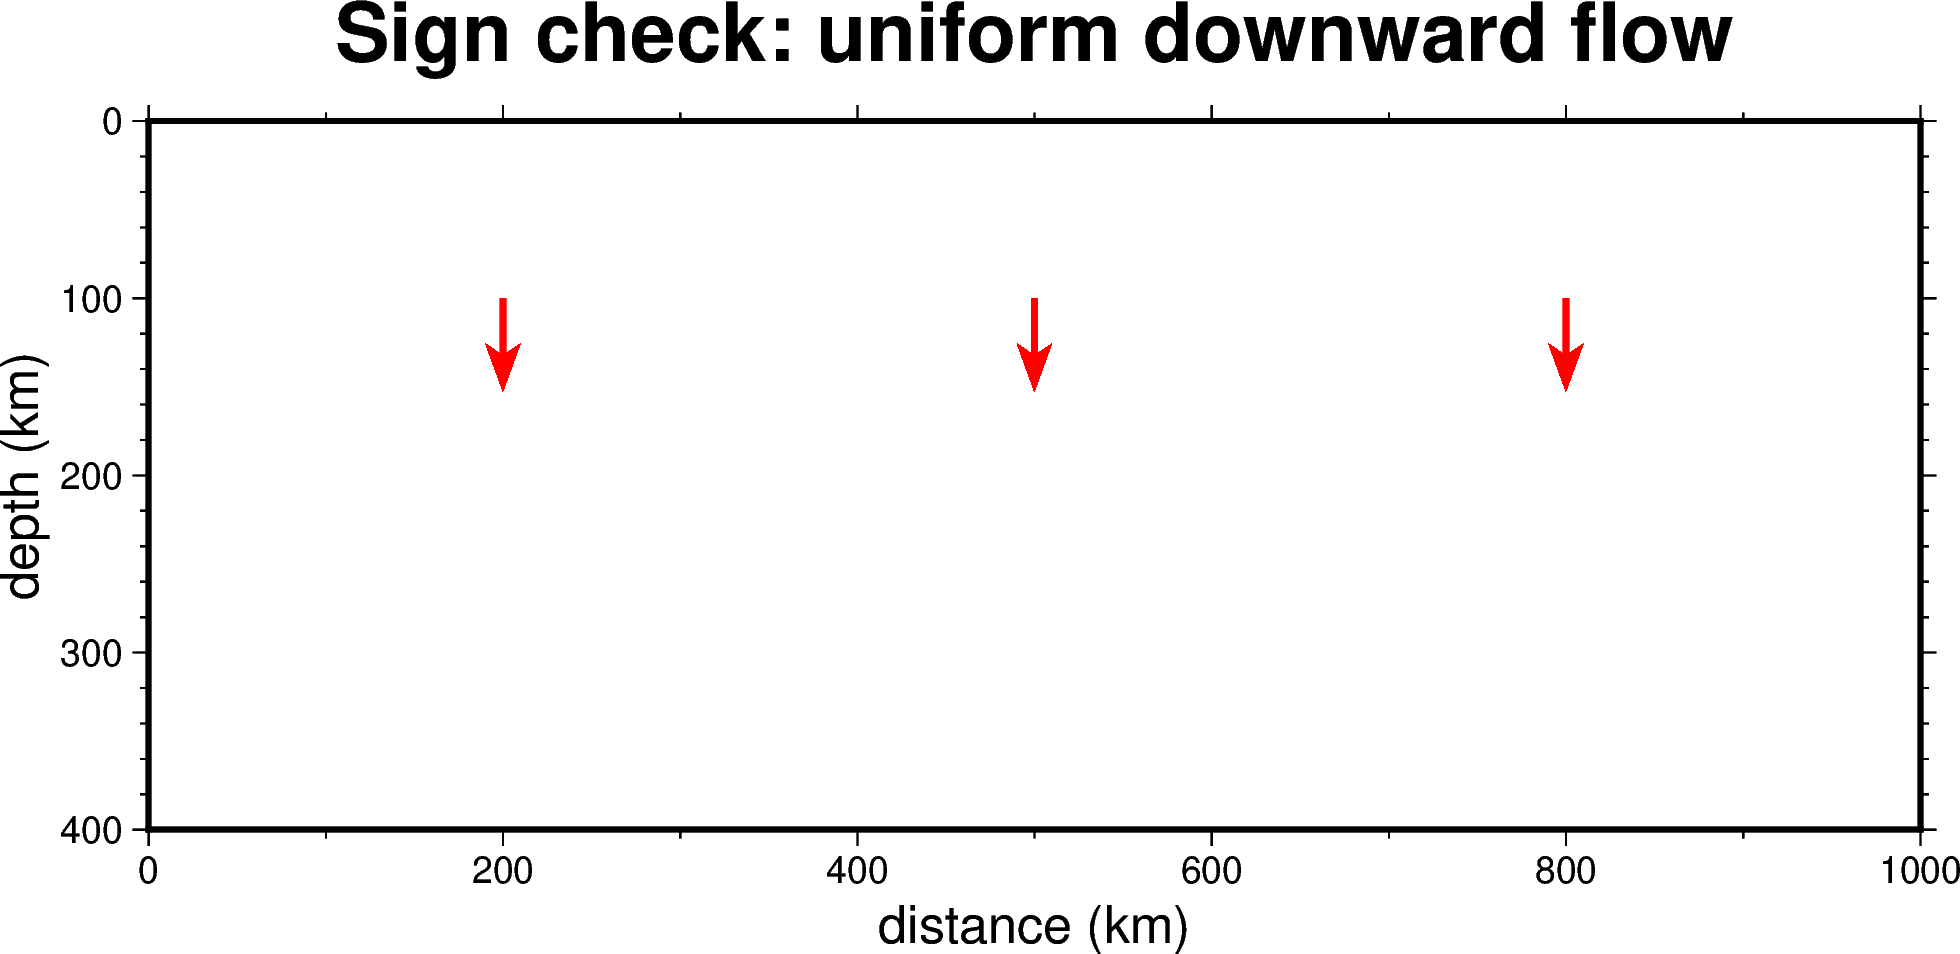

In [7]:
xt = np.array([200.0, 500.0, 800.0])
zt = np.array([100.0, 100.0, 100.0])

fig = pygmt.Figure()
fig.basemap(region=region, projection=projection,
            frame=["WSne+tSign check: uniform downward flow",
                   "xaf+ldistance (km)", "yaf+ldepth (km)"])
fig.plot(x=xt, y=zt, style="v0.4c+e+a40+gred+z2c",
         direction=[np.zeros(3), np.ones(3)],   # vx = 0, vz = +1 (downwards)
         pen="1.5p,red")
fig.show()

## 6. Putting it together

`plotting.field_panel` assembles the standard panel: raster, contours, a
highlighted isotherm, velocity arrows and a colourbar. Note
`interpolation="n"` — nearest neighbour, so you see the *actual model cells*
rather than a smoothed image. For teaching that honesty is worth more than
prettiness.

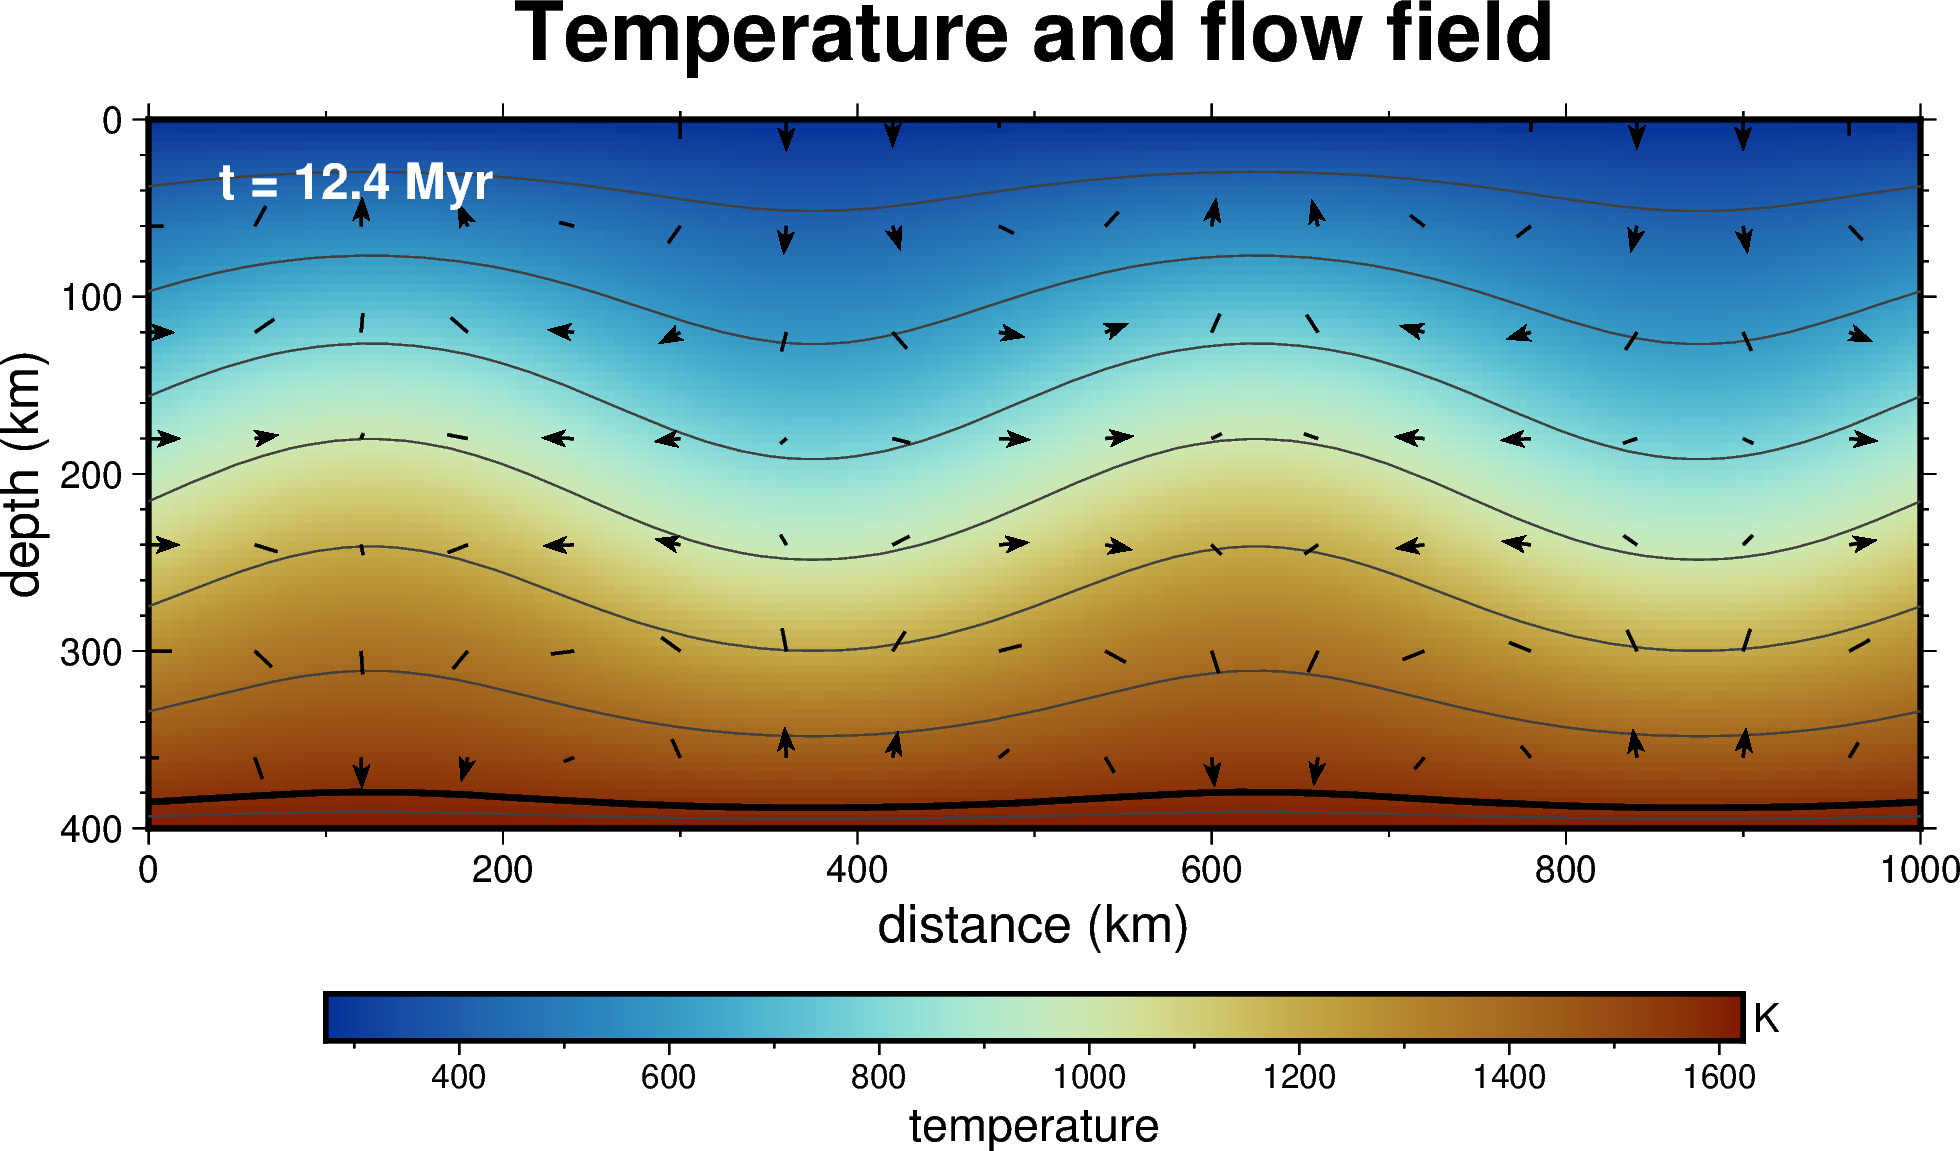

In [8]:
fig = plotting.field_panel(
    T, x, z,
    kind="temperature",
    title="Temperature and flow field",
    label="temperature", unit="K",
    contours=200,
    highlight=1573.0,          # a lithosphere-asthenosphere proxy isotherm
    vx=vx, vz=vz, every=ARROW_EVERY,
    stamp="t = 12.4 Myr",
    width_cm=FIG_WIDTH_CM,
)
fig.show()

Read the figure against the equations: upwelling limbs sit under the warm
bulges, the 1573 K isotherm shallows above them, and flow converges at the cold
downwellings. If the arrows disagreed with the temperature pattern, the sign
convention would be wrong — which is exactly the check section 5 automates.

## 7. Streamlines

**GMT has no streamline module.** The only workaround suggested in the
community is contouring a `grdgradient` aspect angle, which contours a scalar
where you wanted a vector — do not teach it. Instead we integrate in Python and
plot polylines.

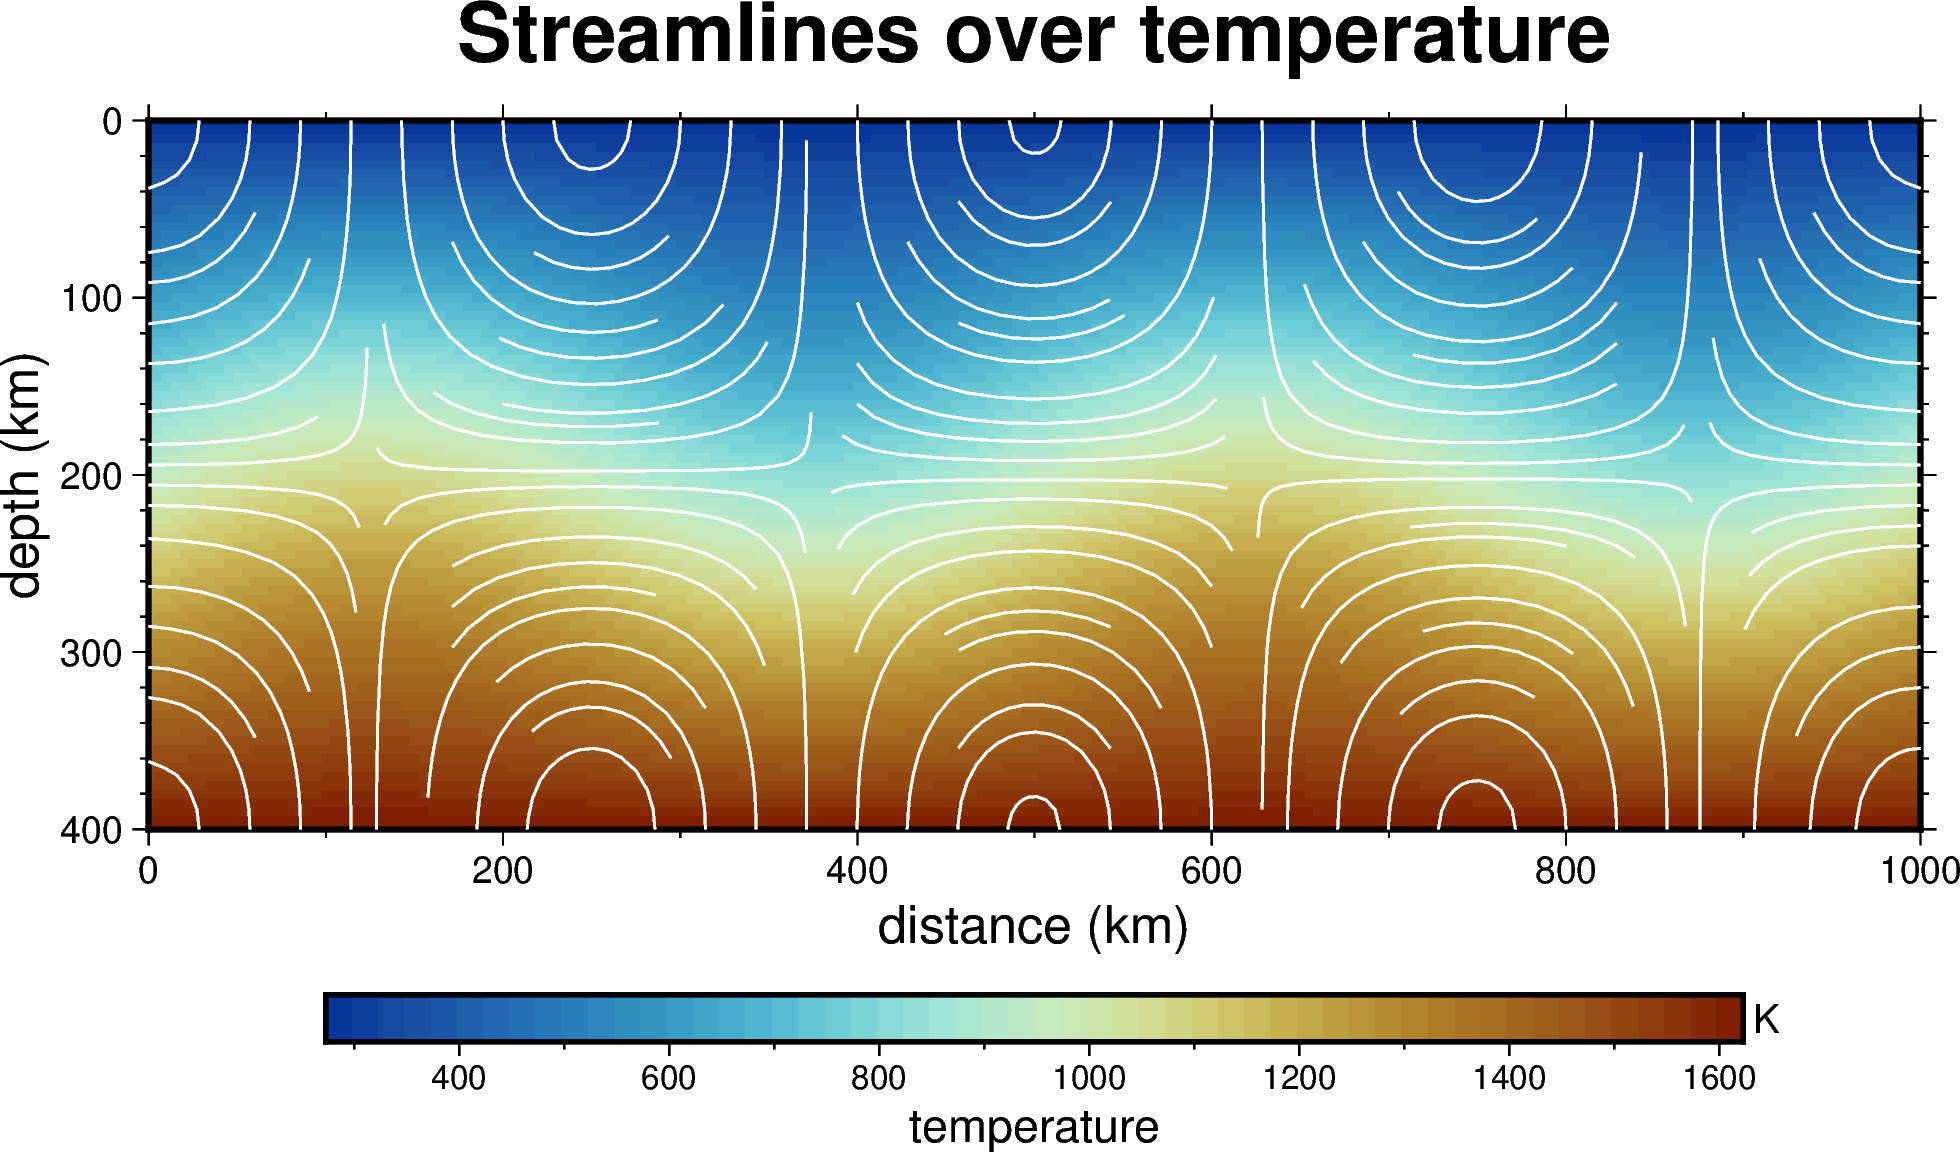

96 streamline segments, integrated in Python


In [9]:
fig = pygmt.Figure()
pygmt.makecpt(cmap="SCM/roma", series=[T.min(), T.max(), 25], reverse=True)
fig.grdimage(grid=temp, region=region, projection=projection, cmap=True,
             frame=plotting.box_frame("Streamlines over temperature"))
n_seg = plotting.streamlines(fig, x, z, vx, vz, density=1.2, pen="0.6p,white")
fig.colorbar(position="JBC+w12c/0.4c+h+o0c/1.4c", frame=["xaf+ltemperature", "y+lK"])
fig.show()
print(f"{n_seg} streamline segments, integrated in Python")

## 8. Where pyGMT is the wrong tool

Being honest about this matters more than advocacy. pyGMT is excellent for
fields, sections and animations — publication-grade typography, Crameri colour
maps built in, and the same vocabulary as command-line GMT. It is *awkward* for
scalar diagnostics: log axes, twin axes and insets are all possible but the
`-B` syntax fights you.

**The policy for this suite: fields and sections in pyGMT, scalar diagnostics
in matplotlib.** Both libraries are in `environment.yml` for exactly this
reason, and the EarthByte GPlately-pyGMT suite does the same.

Other limitations you will meet later:

| Limitation | What to do |
|---|---|
| No `grdvector` wrapper | decimate + `plot(style="v")`, as above |
| No streamlines | integrate in Python (section 7) |
| No `contourf` | `grdimage` with a discrete CPT + `grdcontour` overlay |
| No unstructured/FEM mesh rendering | resample to a regular grid first — notebook T07 does this for a real finite-element solution |
| Graded meshes rejected | resample; `to_grid` will tell you |
| Large marker swarms are slow | subsample, or bin to a grid |

## 9. Animations

**Do not use the GMT `movie` module.** It accepts only sh/bash/csh/bat main
scripts — Python is not supported — and it needs FFmpeg *and* GraphicsMagick on
`PATH`. That destroys platform independence.

Loop in Python, save PNG frames, stitch with imageio or ffmpeg. Frame
generation parallelises with `multiprocessing` — use **processes, not threads**,
because GMT sessions are process-scoped.

In [10]:
import time

t0 = time.time()
frames = []
for k, phase in enumerate(np.linspace(0, np.pi, 3)):
    Tk = (273.0 + 1350.0 * (Z / BOX_Z_KM)
          + 120.0 * np.sin(2 * np.pi * X / 500.0 + phase)
          * np.sin(np.pi * Z / BOX_Z_KM))
    f = plotting.field_panel(Tk, x, z, title="Animation frame",
                             label="temperature", unit="K",
                             stamp=f"t = {k * 5.0:.1f} Myr", width_cm=12.0)
    fname = f"_frame_{k:04d}.png"
    f.savefig(fname, dpi=120)
    frames.append(fname)

print(f"{len(frames)} frames in {time.time() - t0:.2f} s "
      f"({(time.time() - t0) / len(frames):.2f} s per figure)")
print("stitch with: imageio.mimsave('run.mp4', [imageio.imread(f) for f in frames], fps=12)")

3 frames in 0.52 s (0.17 s per figure)
stitch with: imageio.mimsave('run.mp4', [imageio.imread(f) for f in frames], fps=12)


In [11]:
import os
for f in frames:
    os.remove(f)

## Extend this

* Swap `SCM/roma` for `SCM/vik` and plot the temperature *anomaly* (T minus its
  horizontal mean) instead of absolute temperature. Which is more informative?
* Add a second panel with `Figure.subplot` showing the strain-rate second
  invariant beside temperature.
* Time `field_panel` as a function of grid size. At what resolution does figure
  generation start to matter next to the solve?

**Next:** T01 introduces the first actual solver — 1-D heat conduction — and the
difference between a scheme being accurate and being stable.